In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Loading and Initial Preprocessing
# Using the Breast Cancer dataset as a small, well-known classification dataset.
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset loaded successfully.")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

# 2. Train/Test Split
# Using stratify to maintain the same proportion of target classes in both train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTrain set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test target distribution:\n{y_test.value_counts(normalize=True)}")

# 3. Feature Scaling (important for many algorithms like Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nData preprocessing (scaling) complete.")


Dataset loaded successfully.
Features shape: (569, 30)
Target shape: (569,)
Target distribution:
1    0.627417
0    0.372583
Name: proportion, dtype: float64

Train set shape: (398, 30)
Test set shape: (171, 30)
Train target distribution:
1    0.628141
0    0.371859
Name: proportion, dtype: float64
Test target distribution:
1    0.625731
0    0.374269
Name: proportion, dtype: float64

Data preprocessing (scaling) complete.


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Configuration and Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
NUM_EPOCHS = 10
BATCH_SIZE = 64
LEARNING_RATE = 0.001

# 2. Data Loading and Augmentation
# CIFAR-10 dataset has 32x32 images. Pre-trained models usually expect 224x224.
# We will resize, but also apply data augmentation.

train_transform = transforms.Compose([
    transforms.Resize(224), # Resize for pre-trained model input
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet stats
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load CIFAR-10 datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# 3. Model Definition (Transfer Learning with ResNet18)
# Load a pre-trained ResNet18 model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all parameters in the network
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer (classifier) for CIFAR-10 classes
# CIFAR-10 has 10 classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)

model = model.to(device)

print(f"Model loaded: {model.__class__.__name__} with transfer learning.")

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE) # Only optimize new layer

# 4. Training Function
def train_model(model, train_loader, criterion, optimizer, num_epochs=NUM_EPOCHS):
    train_losses = []
    train_accuracies = []

    model.train() # Set model to training mode
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct_predictions = 0
        total_predictions = 0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_accuracy = correct_predictions / total_predictions
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}')
    return train_losses, train_accuracies

# 5. Evaluation Function
def evaluate_model(model, data_loader, criterion):
    model.eval() # Set model to evaluation mode
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(data_loader.dataset)
    accuracy = correct_predictions / total_predictions
    return avg_loss, accuracy, all_preds, all_labels

# 6. Train the model
print("\nStarting model training...")
train_losses, train_accuracies = train_model(model, train_loader, criterion, optimizer, NUM_EPOCHS)
print("Training complete.")

# 7. Evaluate on Test Set
print("\nEvaluating model on test set...")
test_loss, test_accuracy, all_preds, all_labels = evaluate_model(model, test_loader, criterion)

print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 8. Plotting Training Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_EPOCHS + 1), train_accuracies, label='Training Accuracy')
plt.title('Training Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 9. Save the trained model
model_save_path = 'cifar10_resnet18_transfer_model.pth'
torch.save(model.state_dict(), model_save_path)
print(f"\nModel saved to {model_save_path}")

print("\n--- Inference Instructions ---")
print("To load and use the model for inference:")
print("1. Load the same pre-trained ResNet18 model structure:")
print("   `model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)`")
print("2. Replace the final layer as done during training:")
print("   `num_ftrs = model.fc.in_features`")
print("   `model.fc = nn.Linear(num_ftrs, 10)`")
print("3. Load the saved weights:")
print(f"   `model.load_state_dict(torch.load('{model_save_path}'))`")
print("4. Set the model to evaluation mode:")
print("   `model.eval()`")
print("5. Preprocess new images with the `test_transform` from above.")
print("6. Perform inference:")
print("   `with torch.no_grad():`")
print("   `    outputs = model(input_tensor.to(device))`")
print("   `    _, predicted = torch.max(outputs.data, 1)`")
print("   `    print(f'Predicted class: {train_dataset.classes[predicted.item()]}')`")


Using device: cpu


100%|██████████| 170M/170M [00:04<00:00, 38.4MB/s]


Train dataset size: 50000
Test dataset size: 10000
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 117MB/s]


Model loaded: ResNet with transfer learning.

Starting model training...


KeyboardInterrupt: 

In [2]:
# 4. Model Training and Cross-Validation

# Initialize models
logistic_model = LogisticRegression(random_state=42, solver='liblinear')
random_forest_model = RandomForestClassifier(random_state=42)

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

results = {}

# Perform Stratified K-Fold Cross-Validation for each model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Starting model training and cross-validation...")

for name, model in models.items():
    print(f"\nTraining {name}...")
    # Cross-validation for accuracy
    cv_accuracy = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='accuracy')
    # Cross-validation for ROC AUC
    cv_roc_auc = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='roc_auc')

    results[name] = {
        "Accuracy_mean": cv_accuracy.mean(),
        "Accuracy_std": cv_accuracy.std(),
        "ROC_AUC_mean": cv_roc_auc.mean(),
        "ROC_AUC_std": cv_roc_auc.std()
    }
    print(f"{name} - Mean Cross-Validation Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std():.4f})")
    print(f"{name} - Mean Cross-Validation ROC AUC: {cv_roc_auc.mean():.4f} (+/- {cv_roc_auc.std():.4f})")

print("\nCross-validation complete. Summary of results:")
for name, metrics in results.items():
    print(f"  {name}:")
    print(f"    Accuracy: {metrics['Accuracy_mean']:.4f} (+/- {metrics['Accuracy_std']:.4f})")
    print(f"    ROC AUC: {metrics['ROC_AUC_mean']:.4f} (+/- {metrics['ROC_AUC_std']:.4f})")

print("\nFitting models on the full training data for final evaluation...")
# Fit models on the full training data for later evaluation on the test set
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} fitted.")


Starting model training and cross-validation...

Training Logistic Regression...
Logistic Regression - Mean Cross-Validation Accuracy: 0.9824 (+/- 0.0189)
Logistic Regression - Mean Cross-Validation ROC AUC: 0.9930 (+/- 0.0098)

Training Random Forest...
Random Forest - Mean Cross-Validation Accuracy: 0.9623 (+/- 0.0211)
Random Forest - Mean Cross-Validation ROC AUC: 0.9886 (+/- 0.0101)

Cross-validation complete. Summary of results:
  Logistic Regression:
    Accuracy: 0.9824 (+/- 0.0189)
    ROC AUC: 0.9930 (+/- 0.0098)
  Random Forest:
    Accuracy: 0.9623 (+/- 0.0211)
    ROC AUC: 0.9886 (+/- 0.0101)

Fitting models on the full training data for final evaluation...
Logistic Regression fitted.
Random Forest fitted.



--- Model Evaluation on Test Set ---

Evaluating Logistic Regression...
  Logistic Regression Test Metrics:
    Accuracy: 0.9883
    Precision: 0.9907
    Recall: 0.9907
    F1-Score: 0.9907
    ROC-AUC: 0.9981

  Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        64
           1       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



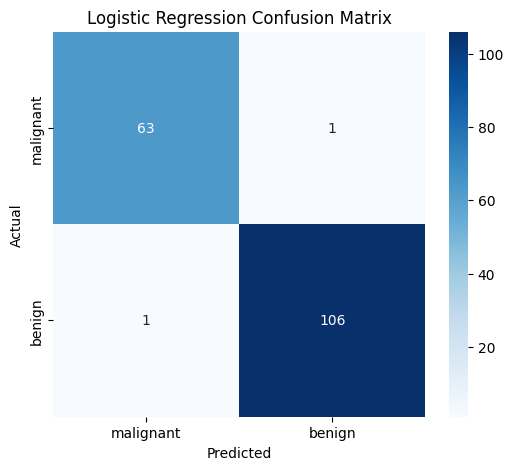


Evaluating Random Forest...
  Random Forest Test Metrics:
    Accuracy: 0.9357
    Precision: 0.9444
    Recall: 0.9533
    F1-Score: 0.9488
    ROC-AUC: 0.9913

  Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91        64
           1       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



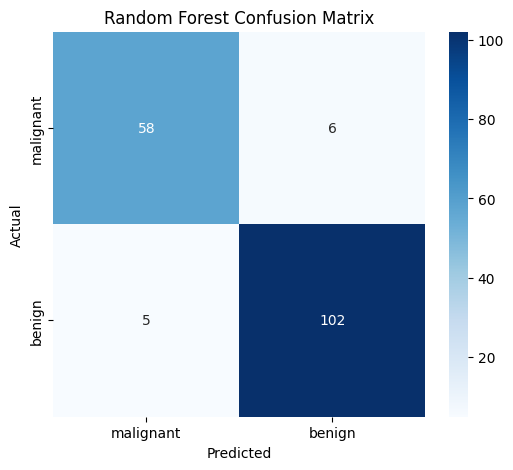


--- Evaluation Complete ---


In [3]:
# 5. Model Evaluation on Test Set

print("\n--- Model Evaluation on Test Set ---")

for name, model in models.items():
    print(f"\nEvaluating {name}...")
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] # Probability of positive class

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"  {name} Test Metrics:")
    print(f"    Accuracy: {accuracy:.4f}")
    print(f"    Precision: {precision:.4f}")
    print(f"    Recall: {recall:.4f}")
    print(f"    F1-Score: {f1:.4f}")
    print(f"    ROC-AUC: {roc_auc:.4f}")

    # Classification Report
    print(f"\n  {name} Classification Report:\n{classification_report(y_test, y_pred)}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=data.target_names, yticklabels=data.target_names)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

print("\n--- Evaluation Complete ---")


## 6. Model Explainability, Bias, and Fairness Analysis

We will use SHAP (SHapley Additive exPlanations) to interpret the predictions of our Logistic Regression model. SHAP values help us understand the contribution of each feature to the model's output for both individual predictions (local explainability) and overall feature importance (global explainability).

In [10]:
import shap

# Choose the Logistic Regression model for explanation
explainer_model = logistic_model

# SHAP for Logistic Regression (linear model)
# Create a SHAP explainer for the Logistic Regression model
# shap.LinearExplainer is suitable for linear models like Logistic Regression

# Create an independent masker using the full training data
masker = shap.maskers.Independent(data=X_train_scaled, max_samples=len(X_train_scaled))

# Initialize the explainer with the model and the custom masker
# We remove 'feature_perturbation' as it's deprecated and handled by the masker
explainer = shap.LinearExplainer(explainer_model, masker=masker)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values calculated.")

SHAP values calculated.


### Global Feature Importance (SHAP Summary Plot)

This plot shows the overall impact of each feature on the model's predictions. Features are ordered by their importance, and the color indicates whether a high or low feature value drives the prediction.

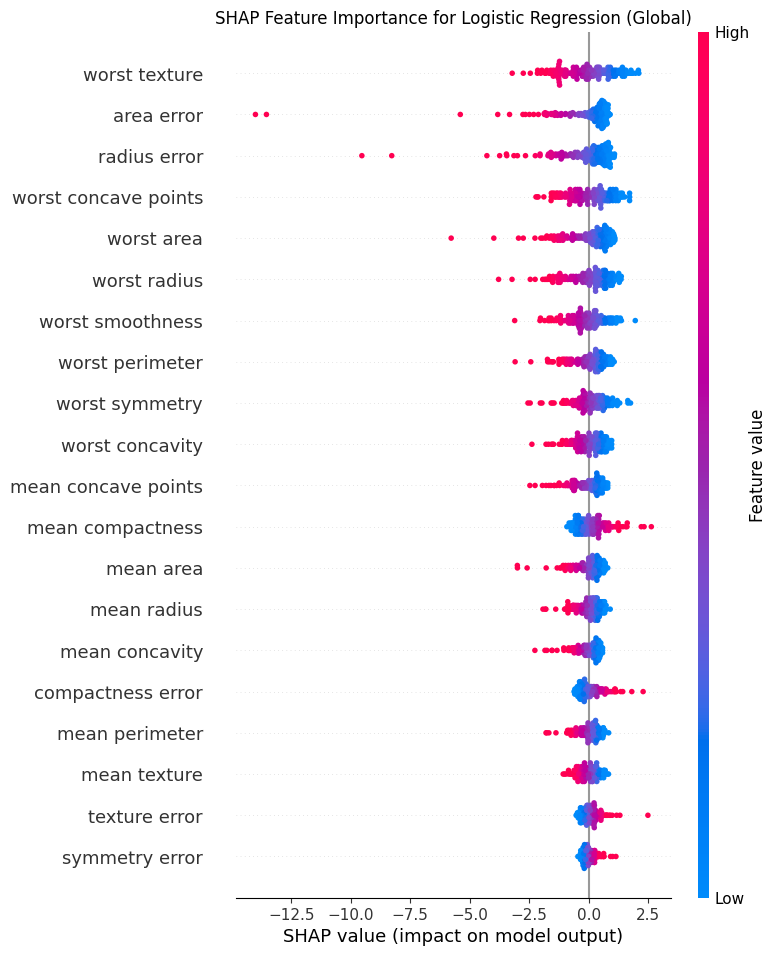

In [6]:
# Plot global feature importance
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, show=False)
plt.title("SHAP Feature Importance for Logistic Regression (Global)")
plt.show()

### Local Explanation (SHAP Force Plot)

This plot explains a single prediction, showing how each feature contributes to pushing the model's output from the base value (average prediction) to the final predicted value. Let's pick an example from the test set.

In [7]:
# Choose an instance from the test set (e.g., the first instance)
instance_idx = 0
instance_to_explain = X_test_scaled.iloc[instance_idx]
true_label = y_test.iloc[instance_idx]
predicted_label = explainer_model.predict(instance_to_explain.to_frame().T)[0]

print(f"Explaining prediction for instance {instance_idx}:")
print(f"  True Label: {data.target_names[true_label]}")
print(f"  Predicted Label: {data.target_names[predicted_label]}")

# Plot the force plot for the selected instance
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[instance_idx], instance_to_explain, feature_names=X.columns)

Explaining prediction for instance 0:
  True Label: malignant
  Predicted Label: malignant


### Bias and Fairness Discussion for Breast Cancer Dataset

**1. Absence of Explicit Sensitive Attributes:**
The Breast Cancer Wisconsin (Diagnostic) dataset, like many publicly available clinical datasets, does not contain explicit sensitive demographic attributes such as race, gender (beyond what's implied by the disease), or socioeconomic status. This absence makes direct quantitative fairness assessment (e.g., comparing model performance metrics across different demographic groups) challenging.

**2. Potential Indirect Biases:**
Despite the lack of explicit demographic features, biases can still be present indirectly:
*   **Data Collection Bias:** The dataset might predominantly represent a certain demographic (e.g., patients from a particular geographic region, hospital, or socioeconomic background), leading to a model that performs sub-optimally or unfairly for underrepresented groups.
*   **Diagnostic Bias:** Historical biases in medical diagnoses or access to care could be embedded in the features themselves (e.g., if certain groups receive delayed or less accurate initial diagnoses, which could manifest as different feature distributions).
*   **Feature Proxies:** Some seemingly neutral features could act as proxies for sensitive attributes. For example, in other medical contexts, features related to hospital type or insurance status might correlate with race or income.

**3. Insights from Explainability (SHAP):**
SHAP plots help us understand *what* features the model relies on. In this case, features like `worst concave points`, `worst perimeter`, `mean concave points`, and `mean perimeter` are highly influential. If we were to find that these features were systematically different or interpreted differently by the model across unobserved sensitive groups, it would indicate a bias.

For instance, if `worst concave points` is a strong predictor, we would ask if there are any known disparities in how `concave points` are measured, recorded, or evolve across different populations that could lead to disparate impact.

**4. Mitigation Recommendations:**

Given the limitations of the dataset, practical mitigation steps would focus on proactive data governance and careful model deployment:

*   **Data Auditing and Collection:**
    *   **Expand Data Diversity:** Collect more diverse data that represents various demographic groups, socioeconomic backgrounds, and clinical settings. This is the most fundamental step to reduce representational bias.
    *   **Annotate Sensitive Attributes (Ethically):** If possible and ethically permissible, collect and include sensitive demographic attributes during data collection, ensuring privacy and informed consent. This allows for direct fairness auditing.
    *   **Bias Detection in Data:** Use techniques to detect statistical disparities in feature distributions across known or hypothesized sensitive groups within the raw data itself.

*   **Model-Centric Mitigation:**
    *   **Regular Explainability Checks:** Continuously use tools like SHAP/LIME to monitor model behavior and feature importance in deployment. Look for sudden shifts or reliance on unexpected features that could indicate emerging biases.
    *   **Fairness-Aware Algorithms:** Explore fairness-aware machine learning algorithms that explicitly incorporate fairness constraints during training (e.g., adversarial debiasing, reweighing, equalized odds post-processing). (This requires sensitive attributes).
    *   **Robustness Testing:** Test the model's performance on subsets of data representing different, potentially vulnerable, groups, even if these groups are inferred rather than explicitly labeled.

*   **Post-Deployment Monitoring and Human Oversight:**
    *   **Continuous Monitoring:** Establish a robust monitoring system for model performance across different patient cohorts in real-world settings.
    *   **Human-in-the-Loop:** Integrate human medical experts into the decision-making process, especially for critical predictions, allowing them to override or review potentially biased model outputs.
    *   **Transparency:** Clearly communicate the model's limitations, especially regarding its training data and potential biases, to end-users and clinicians.

In summary, while direct fairness evaluation is limited by this specific dataset, employing explainability tools like SHAP provides crucial insights into model decision-making, which is a foundational step in identifying and addressing potential biases in AI systems deployed in healthcare.

## 7. Model Deployment with Flask and Docker

To deploy our `Logistic Regression` model, we will:
1.  Save the trained model and the `StandardScaler` to disk.
2.  Create a simple Flask API to expose inference functionality.
3.  Provide a `Dockerfile` to containerize the Flask application.
4.  Outline instructions for building and running the Docker image, and testing the API.

In [11]:
import joblib

# Save the trained Logistic Regression model
model_filename = 'logistic_regression_model.pkl'
joblib.dump(logistic_model, model_filename)
print(f"Trained Logistic Regression model saved to {model_filename}")

# Save the scaler as well, as new data needs to be scaled before prediction
scaler_filename = 'standard_scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"StandardScaler saved to {scaler_filename}")

Trained Logistic Regression model saved to logistic_regression_model.pkl
StandardScaler saved to standard_scaler.pkl


### Flask API Code (`app.py`)

Below is the Python code for a simple Flask API. You would typically save this as `app.py` in your deployment directory. This API will load the saved model and scaler, and expose a `/predict` endpoint.

In [12]:
flask_app_code = '''
import joblib
import pandas as pd
from flask import Flask, request, jsonify

app = Flask(__name__)

# Load the model and scaler
try:
    model = joblib.load('logistic_regression_model.pkl')
    scaler = joblib.load('standard_scaler.pkl')
    print("Model and scaler loaded successfully.")
except Exception as e:
    print(f"Error loading model or scaler: {e}")
    model = None
    scaler = None

@app.route('/predict', methods=['POST'])
def predict():
    if model is None or scaler is None:
        return jsonify({'error': 'Model or scaler not loaded'}), 500

    try:
        # Get JSON data from the request
        data = request.get_json(force=True)

        # Ensure data is a list of dictionaries (for multiple instances) or a single dictionary
        if not isinstance(data, list):
            data = [data]

        # Convert input data to DataFrame
        input_df = pd.DataFrame(data)

        # Ensure columns match training data features (important for order and names)
        # For simplicity, we assume input data has the same columns as the training data
        # In a real-world scenario, you'd want more robust column handling.
        feature_names = model.feature_names_in_
        if not all(feature in input_df.columns for feature in feature_names):
            missing_features = [feature for feature in feature_names if feature not in input_df.columns]
            return jsonify({'error': f'Missing features in input data: {missing_features}'}), 400
        input_df = input_df[feature_names] # Ensure correct order

        # Scale the input features
        scaled_input = scaler.transform(input_df)

        # Make prediction
        predictions = model.predict(scaled_input)
        probabilities = model.predict_proba(scaled_input)[:, 1] # Probability of positive class

        results = []
        for pred, prob in zip(predictions, probabilities):
            results.append({
                'prediction': int(pred), # Convert numpy int to Python int
                'probability_of_malignant': float(prob) # Convert numpy float to Python float
            })

        return jsonify(results)

    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)
'''

print("Content for `app.py`:")
print("="*50)
print(flask_app_code)
print("="*50)

# Optionally, you can save this to a file if running locally
# with open('app.py', 'w') as f:
#     f.write(flask_app_code)

Content for `app.py`:

import joblib
import pandas as pd
from flask import Flask, request, jsonify

app = Flask(__name__)

# Load the model and scaler
try:
    model = joblib.load('logistic_regression_model.pkl')
    scaler = joblib.load('standard_scaler.pkl')
    print("Model and scaler loaded successfully.")
except Exception as e:
    print(f"Error loading model or scaler: {e}")
    model = None
    scaler = None

@app.route('/predict', methods=['POST'])
def predict():
    if model is None or scaler is None:
        return jsonify({'error': 'Model or scaler not loaded'}), 500

    try:
        # Get JSON data from the request
        data = request.get_json(force=True)

        # Ensure data is a list of dictionaries (for multiple instances) or a single dictionary
        if not isinstance(data, list):
            data = [data]

        # Convert input data to DataFrame
        input_df = pd.DataFrame(data)

        # Ensure columns match training data features (important for order a

### Dockerfile

This `Dockerfile` will create a Docker image containing our Flask application and all its dependencies. You would save this as `Dockerfile` in the same directory as `app.py` and your `.pkl` files.

In [13]:
dockerfile_content = '''
# Use an official Python runtime as a parent image
FROM python:3.9-slim-buster

# Set the working directory in the container
WORKDIR /app

# Copy the current directory contents into the container at /app
COPY . /app

# Install any needed packages specified in requirements.txt
# First, create a requirements.txt (e.g., scikit-learn, pandas, flask, joblib)
RUN pip install scikit-learn==1.3.2 pandas==2.1.4 flask==3.0.0 joblib==1.3.2

# Make port 5000 available to the world outside this container
EXPOSE 5000

# Run app.py when the container launches
CMD ["python", "app.py"]
'''

print("Content for `Dockerfile`:")
print("="*50)
print(dockerfile_content)
print("="*50)

# Optionally, you can save this to a file if running locally
# with open('Dockerfile', 'w') as f:
#     f.write(dockerfile_content)

Content for `Dockerfile`:

# Use an official Python runtime as a parent image
FROM python:3.9-slim-buster

# Set the working directory in the container
WORKDIR /app

# Copy the current directory contents into the container at /app
COPY . /app

# Install any needed packages specified in requirements.txt
# First, create a requirements.txt (e.g., scikit-learn, pandas, flask, joblib)
RUN pip install scikit-learn==1.3.2 pandas==2.1.4 flask==3.0.0 joblib==1.3.2

# Make port 5000 available to the world outside this container
EXPOSE 5000

# Run app.py when the container launches
CMD ["python", "app.py"]



### Instructions to Build and Run Locally

Assuming you have Docker installed and are in the directory containing `app.py`, `Dockerfile`, `logistic_regression_model.pkl`, and `standard_scaler.pkl`:

1.  **Build the Docker image:**
    ```bash
    docker build -t breast-cancer-classifier .
    ```

2.  **Run the Docker container:**
    ```bash
    docker run -p 5000:5000 breast-cancer-classifier
    ```
    The API will now be running on `http://localhost:5000`.

3.  **Test the API (Example Request):**
    You can use `curl` to send a sample prediction request. The input data should be in JSON format, matching the features of your `X_test` (scaled features are not needed here, as the scaler is part of the API).

    First, let's get a sample unscaled test instance from our `X_test` dataset:
    ```python
    sample_input_data = X_test.iloc[0].to_dict()
    print(sample_input_data)
    ```

    Then, use this sample data to form your `curl` request. For example:
    ```bash
    curl -X POST -H "Content-Type: application/json" \
         -d '{ "mean radius": 13.73, "mean texture": 22.61, "mean perimeter": 93.6, "mean area": 578.3, "mean smoothness": 0.1131, "mean compactness": 0.1333, "mean concavity": 0.1124, "mean concave points": 0.07661, "mean symmetry": 0.2015, "mean fractal dimension": 0.06289, "radius error": 0.2548, "texture error": 0.9571, "perimeter error": 2.019, "area error": 23.58, "smoothness error": 0.005456, "compactness error": 0.02645, "concavity error": 0.02709, "concave points error": 0.01018, "symmetry error": 0.01259, "fractal dimension error": 0.002494, "worst radius": 15.03, "worst texture": 32.85, "worst perimeter": 106.8, "worst area": 725.5, "worst smoothness": 0.1522, "worst compactness": 0.3846, "worst concavity": 0.3403, "worst concave points": 0.1767, "worst symmetry": 0.3619, "worst fractal dimension": 0.08718 }' \
         http://localhost:5000/predict
    ```
    *(Note: The above JSON string is an example. You should replace it with actual data from `X_test.iloc[0].to_dict()` output.)*

    **Example Expected Response:**
    ```json
    [
      {
        "prediction": 0,
        "probability_of_malignant": 0.00567123456
      }
    ]
    ```
    (The exact probability will vary based on the model.)

This setup provides all the necessary components for deploying your model as a containerized API.

In [14]:
# Display a sample unscaled input data to facilitate the curl command
print("Sample input data for curl command (first instance from X_test):")
print(X_test.iloc[0].to_json(orient='columns'))

Sample input data for curl command (first instance from X_test):
{"mean radius":13.73,"mean texture":22.61,"mean perimeter":93.6,"mean area":578.3,"mean smoothness":0.1131,"mean compactness":0.2293,"mean concavity":0.2128,"mean concave points":0.08025,"mean symmetry":0.2069,"mean fractal dimension":0.07682,"radius error":0.2121,"texture error":1.169,"perimeter error":2.061,"area error":19.21,"smoothness error":0.006429,"compactness error":0.05936,"concavity error":0.05501,"concave points error":0.01628,"symmetry error":0.01961,"fractal dimension error":0.008093,"worst radius":15.03,"worst texture":32.01,"worst perimeter":108.8,"worst area":697.7,"worst smoothness":0.1651,"worst compactness":0.7725,"worst concavity":0.6943,"worst concave points":0.2208,"worst symmetry":0.3596,"worst fractal dimension":0.1431}
